# Synthetic phantom — transparent surface + centerline

Renders Block 1 `surface_Synthetic.vtp` with black centerline and blue endpoints for `Synthetic_1` (healthy) and `Synthetic_2` (stenosis).

**Area / %AS surface colormaps:** export from the Streamlit dashboard.

**Exports:** `exports/fig_synthetic_<n>_surface_tube.png` (this folder only).


## 1. Setup

In [ ]:
from __future__ import annotations

import sys
import types
from pathlib import Path

sys.modules.setdefault(
    "vtkmodules.vtkRenderingMatplotlib",
    types.ModuleType("vtkmodules.vtkRenderingMatplotlib"),
)

import numpy as np
import pyvista as pv

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR
while not (PROJECT_ROOT / "src" / "blocks" / "_01_extraction.py").is_file():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise RuntimeError(
            "Could not locate repo root. Run Jupyter from the repo or from "
            "notebooks/results visualizations/synthetic."
        )
    PROJECT_ROOT = PROJECT_ROOT.parent

BLOCK1_ROOT = PROJECT_ROOT / "results" / "block1_results"
EXPORT_DIR = NOTEBOOK_DIR / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

for _backend in ("static", "trame", "client"):
    try:
        pv.set_jupyter_backend(_backend)
        print(f"PyVista Jupyter backend: {_backend}")
        break
    except Exception:
        continue

# Match visualizations_01 (Normal_8 / MACS_Normal_8 artery colors)
COLOR_SYNTHETIC_1 = "#6baed6"  # soft blue (RCA)
COLOR_SYNTHETIC_2 = "#fc9272"  # soft red (LCA)
MESH_OPACITY = 0.22
WINDOW_SIZE = (1920, 1400)

SURFACE_VTP_NAME = "surface_Synthetic.vtp"
CENTERLINE_VTP_NAME = "centerline_Synthetic.vtp"

COLOR_CENTERLINE = "black"
COLOR_ENDPOINT = "#3182bd"
CENTERLINE_WIDTH = 4
CENTERLINE_TUBE_RADIUS = 0.35
ENDPOINT_RADIUS = 1.8

SYNTHETIC_CASES: dict[str, dict] = {
    "Synthetic_1": {
        "title": "Synthetic 1 — normal tube",
        "color": COLOR_SYNTHETIC_1,
        "export_stem": "fig_synthetic_1_surface_tube",
        "focus_stenosis": False,
    },
    "Synthetic_2": {
        "title": "Synthetic 2 — stenosis tube",
        "color": COLOR_SYNTHETIC_2,
        "export_stem": "fig_synthetic_2_surface_tube",
        "focus_stenosis": True,
    },
}

print(f"Project root : {PROJECT_ROOT}")
print(f"Block 1 root : {BLOCK1_ROOT}")
print(f"Exports      : {EXPORT_DIR}")

PyVista Jupyter backend: static
Project root : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository
Block 1 root : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block1_results
Exports      : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\synthetic\exports


## 2. Surface + centerline + endpoints (section A)

In [ ]:
def _block1_sample_dir(patient_id: str, block1_root: Path = BLOCK1_ROOT) -> Path:
    return block1_root / patient_id


def load_synthetic_surface(
    patient_id: str,
    *,
    block1_root: Path = BLOCK1_ROOT,
) -> pv.PolyData:
    path = _block1_sample_dir(patient_id, block1_root) / SURFACE_VTP_NAME
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing {SURFACE_VTP_NAME} for {patient_id}.\n"
            f"Expected: {path}\n"
            f"Run the pipeline for {patient_id} first."
        )
    return pv.read(str(path))


def load_synthetic_centerline(
    patient_id: str,
    *,
    block1_root: Path = BLOCK1_ROOT,
) -> pv.PolyData:
    path = _block1_sample_dir(patient_id, block1_root) / CENTERLINE_VTP_NAME
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing {CENTERLINE_VTP_NAME} for {patient_id}.\n"
            f"Expected: {path}\n"
            f"Run the pipeline for {patient_id} first."
        )
    return pv.read(str(path))


def _mesh_bounds(mesh: pv.PolyData) -> tuple[np.ndarray, np.ndarray]:
    b = np.asarray(mesh.bounds, dtype=float)
    return b[::2], b[1::2]


def _tube_axis_index(bmin: np.ndarray, bmax: np.ndarray) -> int:
    """Longest bounding-box axis (phantom tube is along Z)."""
    return int(np.argmax(bmax - bmin))


def _centerline_endpoints(cl: pv.PolyData) -> np.ndarray:
    """Return (2, 3) terminal points of the centerline polyline."""
    pts = np.asarray(cl.points, dtype=float)
    if pts.shape[0] < 2:
        raise ValueError("Centerline has fewer than 2 points")

    endpoint_ids: list[int] = []
    lines = cl.lines
    if lines is not None and len(lines) > 0:
        offset = 0
        degree: dict[int, int] = {}
        while offset < len(lines):
            n = int(lines[offset])
            seg = lines[offset + 1 : offset + 1 + n]
            for vid in seg:
                degree[int(vid)] = degree.get(int(vid), 0) + 1
            offset += n + 1
        endpoint_ids = [vid for vid, deg in degree.items() if deg == 1]

    if len(endpoint_ids) < 2:
        endpoint_ids = [0, int(pts.shape[0] - 1)]

    return pts[np.array(endpoint_ids[:2], dtype=int)]


def _camera_position_diagonal(
    mesh: pv.PolyData,
    span: float,
    *,
    focus_stenosis: bool = False,
) -> list:
    """
    Side-on diagonal view: tube axis ~horizontal on screen (not vertical).
    Phantom axis is Z; camera sits mainly on +X with a small +Y offset, view-up = +Y.
  """
    bmin, bmax = _mesh_bounds(mesh)
    axis = _tube_axis_index(bmin, bmax)
    center = 0.5 * (bmin + bmax)
    focal = center.copy()

    if focus_stenosis:
        # Frame the mid-tube stenosis (cosine waist along the phantom axis).
        focal[axis] = 0.5 * (bmin[axis] + bmax[axis])

    eye = focal.copy()
    span = float(span) if span > 0 else 1.0
    offsets = np.zeros(3, dtype=float)
    offsets[(axis + 1) % 3] = 1.85 * span
    offsets[(axis + 2) % 3] = 0.45 * span
    offsets[axis] = 0.06 * span
    eye = focal + offsets

    view_up = np.zeros(3, dtype=float)
    view_up[(axis + 2) % 3] = 1.0

    return [eye.tolist(), focal.tolist(), view_up.tolist()]


def _shared_camera_span(patient_ids: list[str]) -> float:
    spans: list[float] = []
    for pid in patient_ids:
        mesh = load_synthetic_surface(pid)
        bmin, bmax = _mesh_bounds(mesh)
        spans.append(float(np.max(bmax - bmin)))
    return max(spans) if spans else 1.0


def _centerline_as_tube(
    centerline: pv.PolyData,
    radius: float = CENTERLINE_TUBE_RADIUS,
) -> pv.PolyData:
    """Build a tubular mesh from the centerline (works on all PyVista versions)."""
    return centerline.tube(radius=radius, n_sides=12)


def _add_endpoint_markers(plotter: pv.Plotter, endpoints: np.ndarray) -> None:
    for pt in endpoints:
        plotter.add_mesh(
            pv.Sphere(radius=ENDPOINT_RADIUS, center=pt),
            color=COLOR_ENDPOINT,
            opacity=1.0,
            smooth_shading=True,
        )


def render_synthetic_surface(
    patient_id: str,
    *,
    mesh: pv.PolyData | None = None,
    centerline: pv.PolyData | None = None,
    color: str,
    title: str,
    camera_span: float,
    focus_stenosis: bool = False,
    show_axes: bool = False,
    off_screen: bool = False,
    screenshot_path: Path | None = None,
) -> pv.Plotter:
    if mesh is None:
        mesh = load_synthetic_surface(patient_id)
    if centerline is None:
        centerline = load_synthetic_centerline(patient_id)

    use_off_screen = off_screen or screenshot_path is not None
    plotter = pv.Plotter(
        off_screen=use_off_screen,
        window_size=WINDOW_SIZE,
        title=title,
    )
    plotter.set_background("white")
    plotter.enable_depth_peeling(number_of_peels=100, occlusion_ratio=0.0)

    plotter.add_mesh(
        mesh,
        color=color,
        opacity=MESH_OPACITY,
        smooth_shading=True,
        show_edges=False,
        name=f"{patient_id}_surface",
    )

    plotter.add_mesh(
        _centerline_as_tube(centerline),
        color=COLOR_CENTERLINE,
        opacity=1.0,
        smooth_shading=True,
        name=f"{patient_id}_centerline",
    )

    endpoints = _centerline_endpoints(centerline)
    _add_endpoint_markers(plotter, endpoints)

    plotter.camera_position = _camera_position_diagonal(
        mesh,
        camera_span,
        focus_stenosis=focus_stenosis,
    )
    plotter.reset_camera_clipping_range()

    if show_axes:
        plotter.add_axes()

    if screenshot_path is not None:
        screenshot_path = Path(screenshot_path)
        screenshot_path.parent.mkdir(parents=True, exist_ok=True)
        plotter.show(screenshot=str(screenshot_path), auto_close=True)
        print(f"Saved: {screenshot_path}")
    elif not use_off_screen:
        plotter.show()

    return plotter


def export_synthetic_surface(patient_id: str, *, stem: str | None = None) -> Path:
    meta = SYNTHETIC_CASES[patient_id]
    stem = stem or meta["export_stem"]
    out_path = EXPORT_DIR / f"{stem}.png"
    render_synthetic_surface(
        patient_id,
        mesh=meshes[patient_id],
        centerline=centerlines[patient_id],
        color=meta["color"],
        title=meta["title"],
        camera_span=SHARED_CAMERA_SPAN,
        focus_stenosis=bool(meta.get("focus_stenosis", False)),
        screenshot_path=out_path,
    )
    return out_path


meshes = {pid: load_synthetic_surface(pid) for pid in SYNTHETIC_CASES}
centerlines = {pid: load_synthetic_centerline(pid) for pid in SYNTHETIC_CASES}
SHARED_CAMERA_SPAN = _shared_camera_span(list(SYNTHETIC_CASES))
print(f"Loaded {len(meshes)} case(s); shared camera span = {SHARED_CAMERA_SPAN:.2f} mm")
for pid in SYNTHETIC_CASES:
    m, cl = meshes[pid], centerlines[pid]
    ep = _centerline_endpoints(cl)
    print(
        f"  {pid}: surface {m.n_points} pts | centerline {cl.n_points} pts | "
        f"endpoints {ep.shape[0]}"
    )

Loaded 2 case(s); shared camera span = 89.64 mm
  Synthetic_1: surface 7782 pts | centerline 279 pts | endpoints 2
  Synthetic_2: surface 7782 pts | centerline 183 pts | endpoints 2


## 3. Preview — Synthetic 1 (section A)

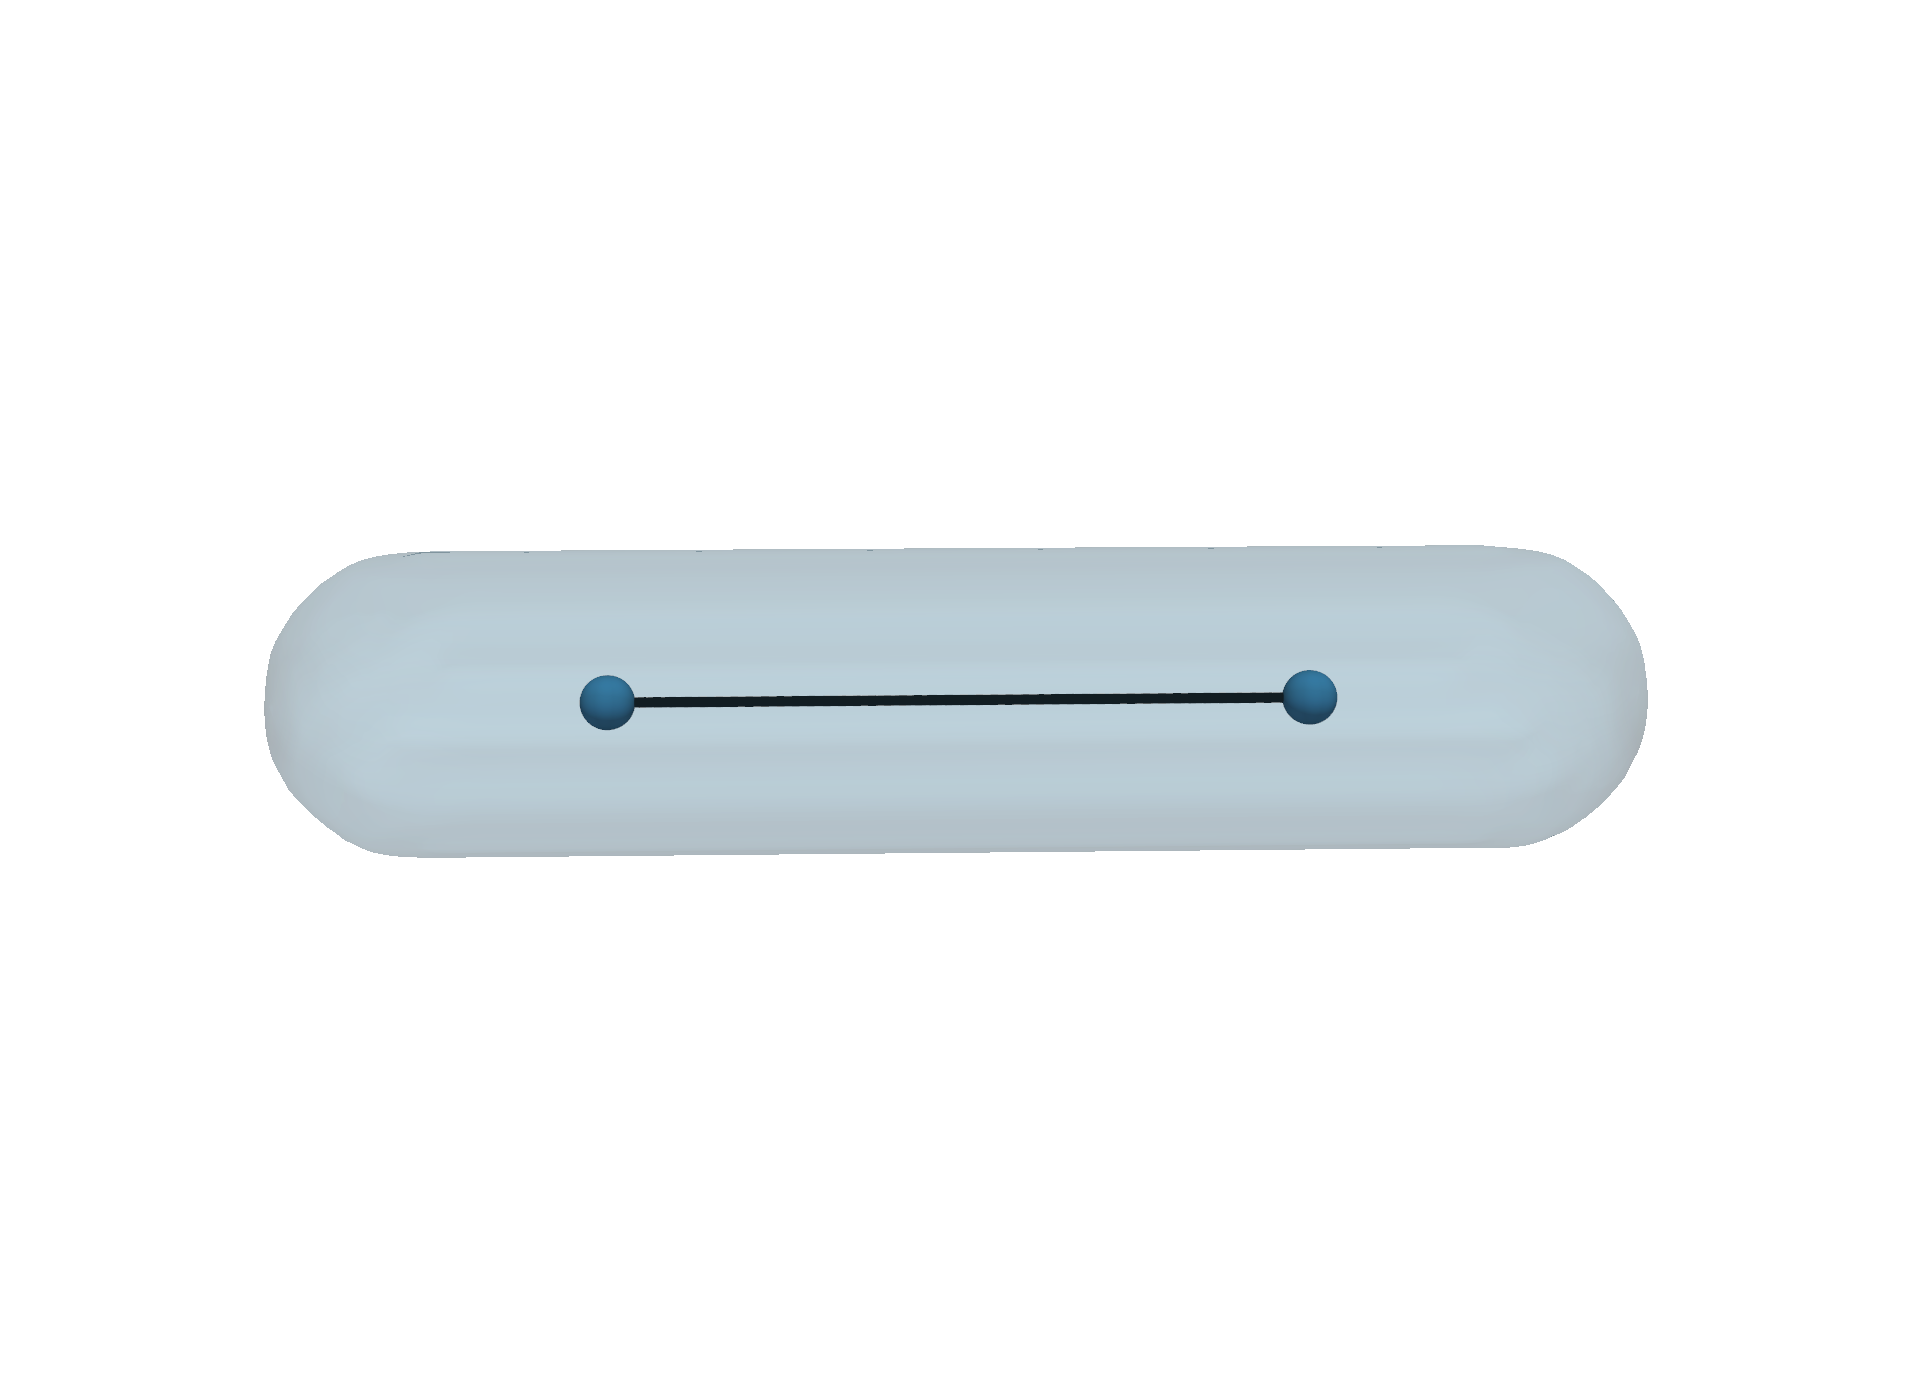

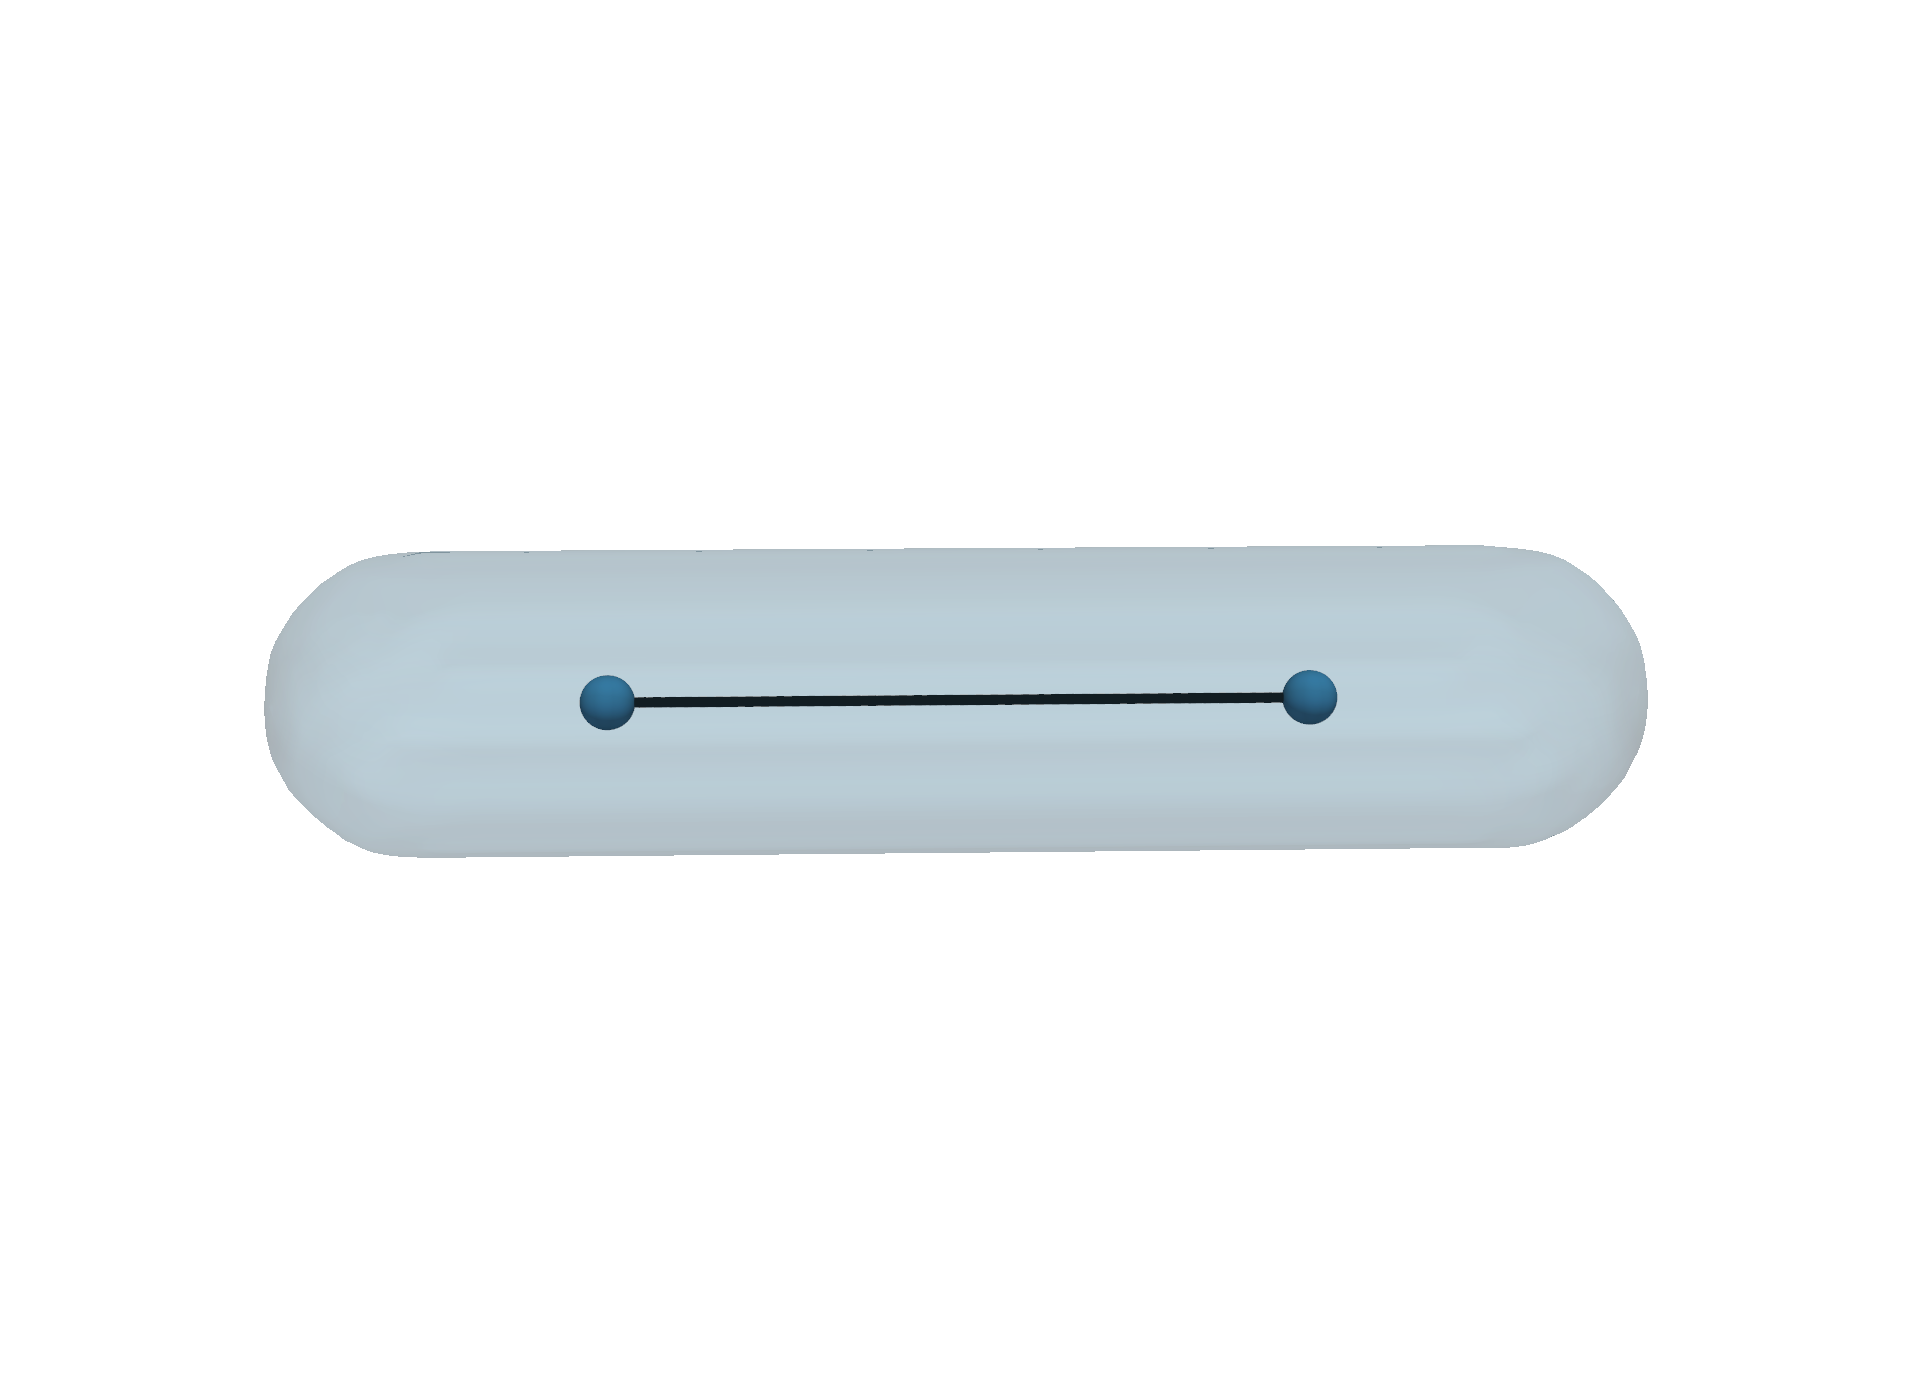

In [ ]:
pid = "Synthetic_1"
meta = SYNTHETIC_CASES[pid]
pl = render_synthetic_surface(
    pid,
    mesh=meshes[pid],
    centerline=centerlines[pid],
    color=meta["color"],
    title=meta["title"],
    camera_span=SHARED_CAMERA_SPAN,
    focus_stenosis=bool(meta.get("focus_stenosis", False)),
)
pl.show()

## 4. Preview — Synthetic 2 (section A)

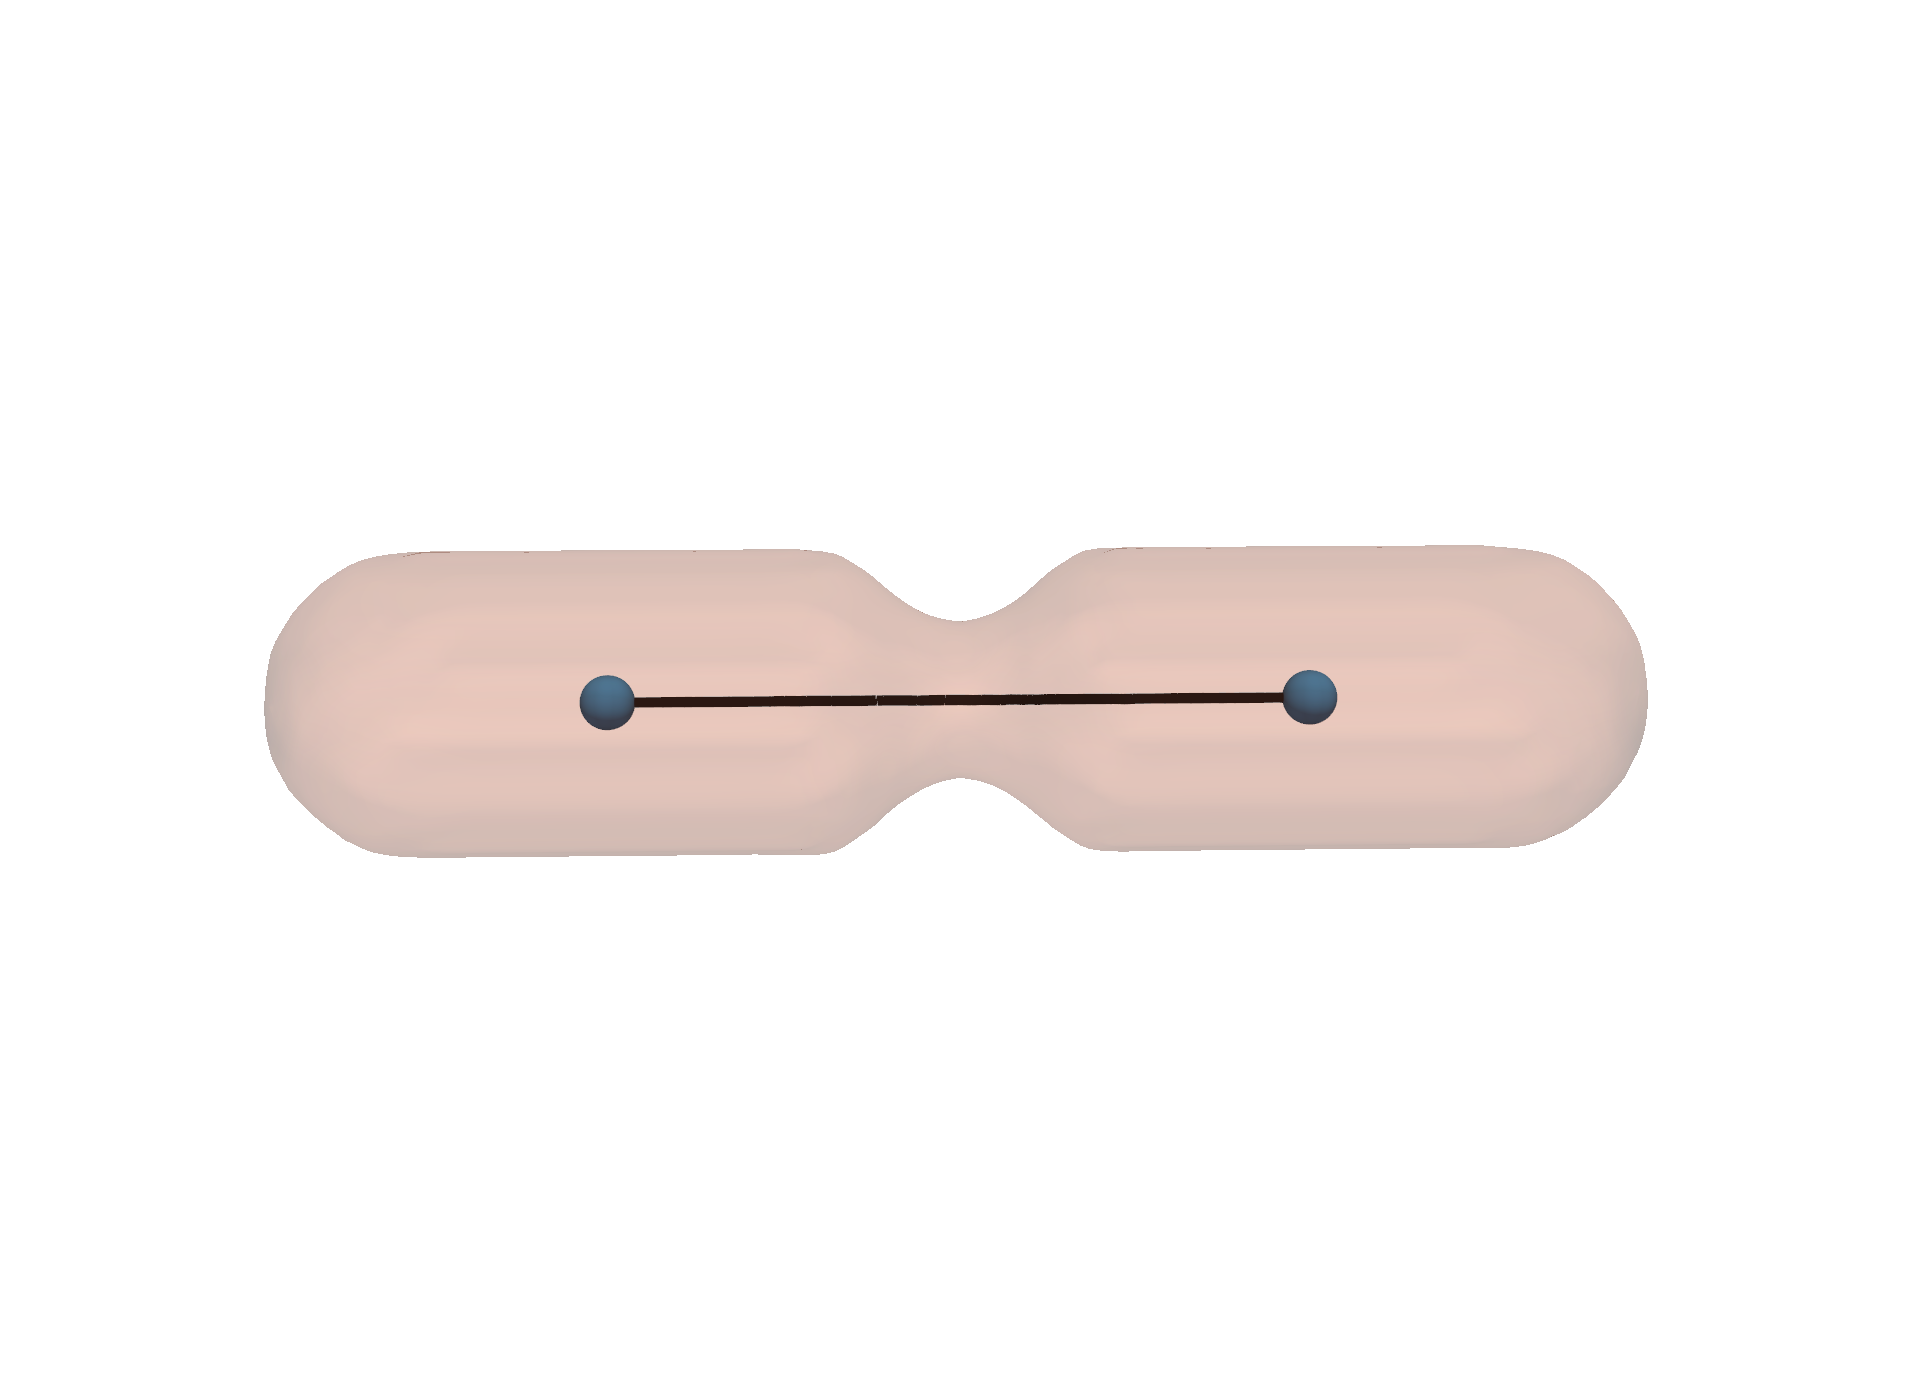

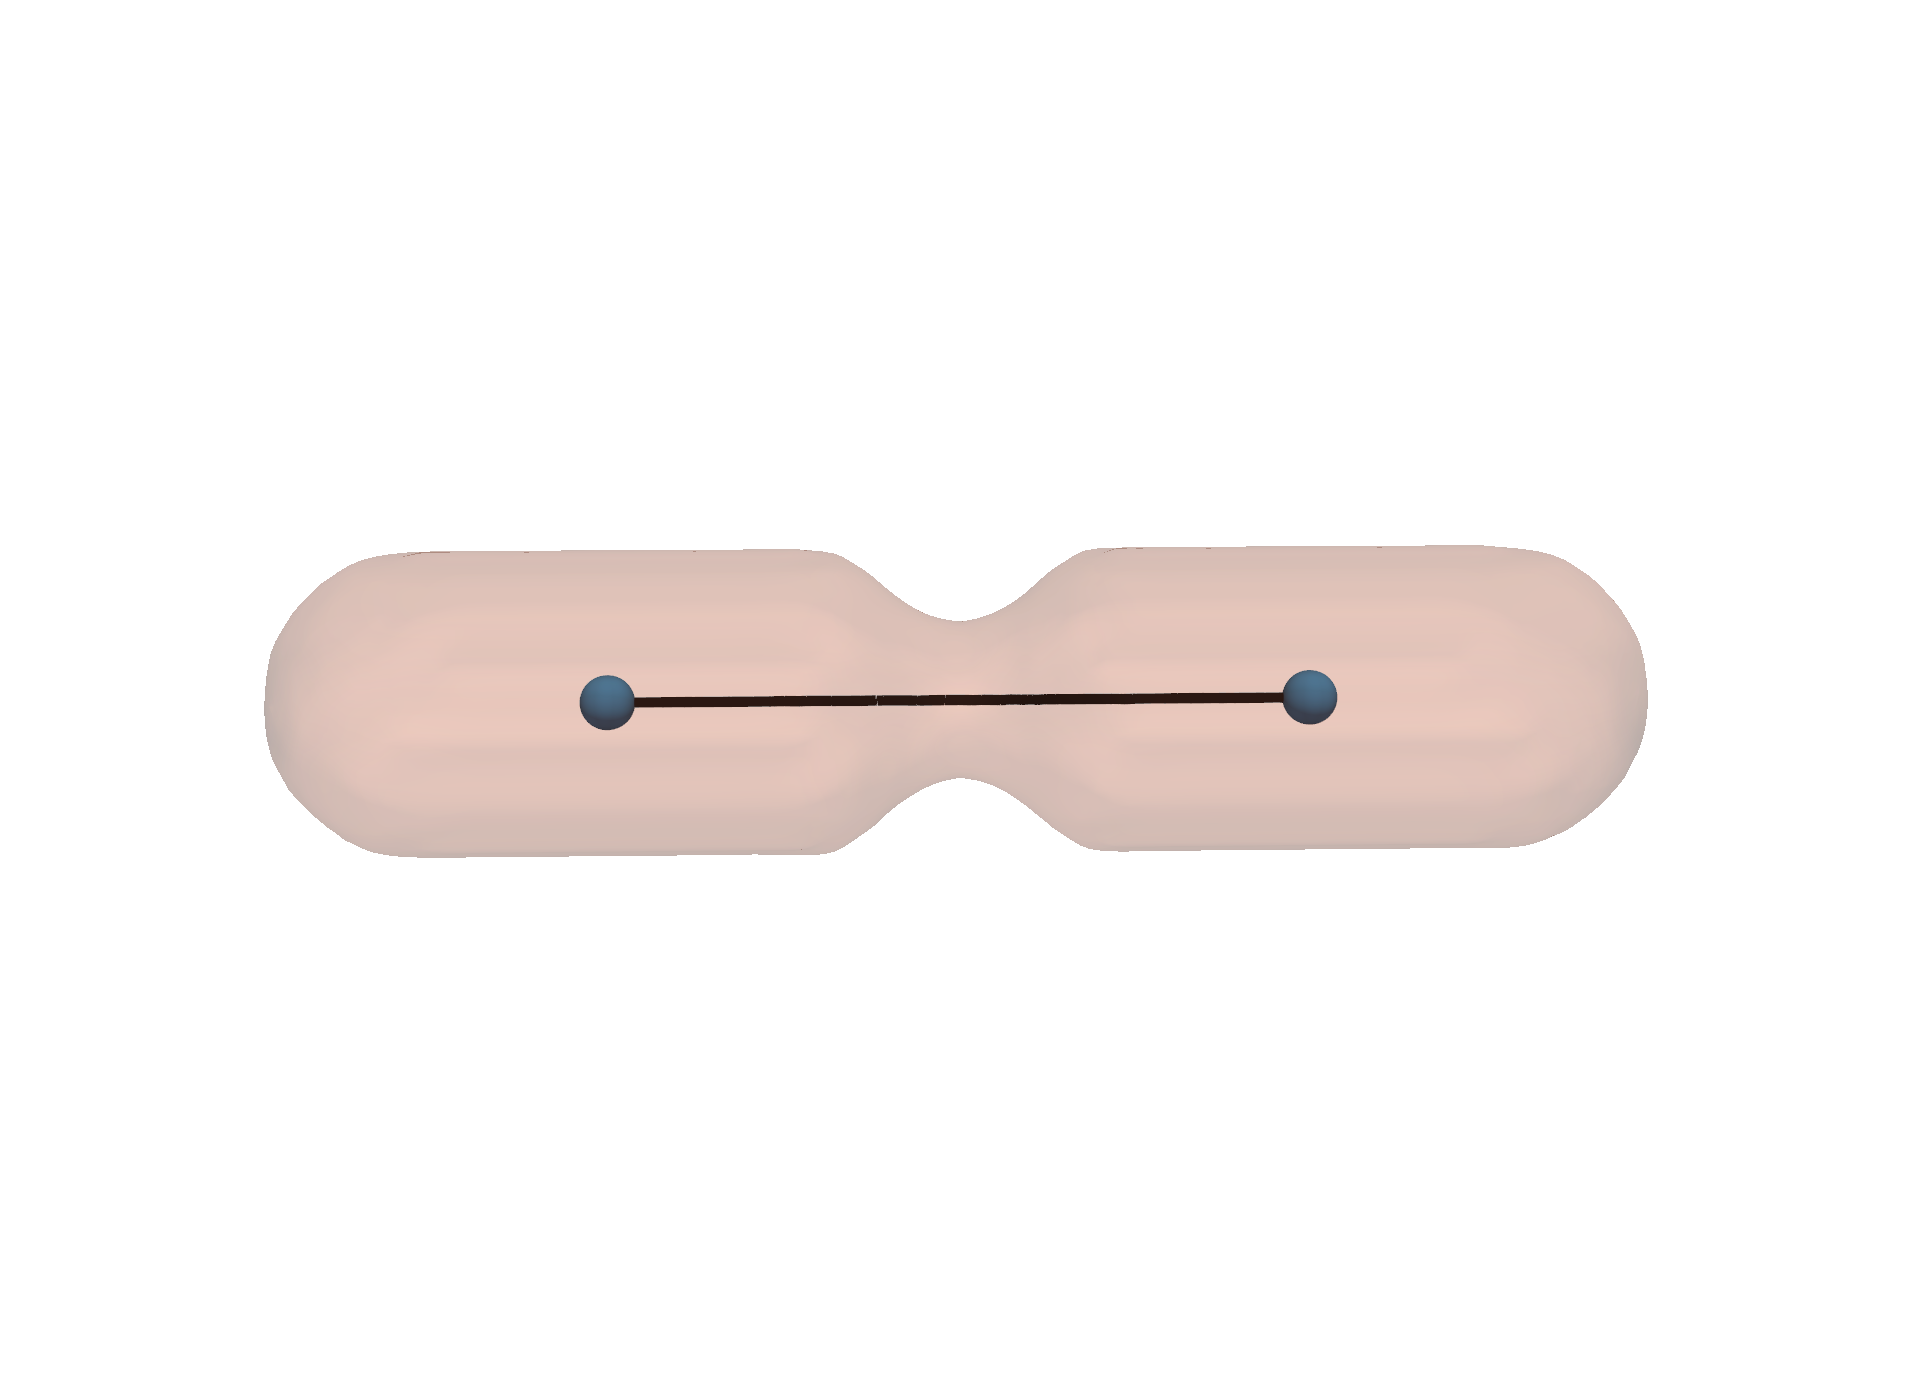

In [ ]:
pid = "Synthetic_2"
meta = SYNTHETIC_CASES[pid]
pl = render_synthetic_surface(
    pid,
    mesh=meshes[pid],
    centerline=centerlines[pid],
    color=meta["color"],
    title=meta["title"],
    camera_span=SHARED_CAMERA_SPAN,
    focus_stenosis=bool(meta.get("focus_stenosis", False)),
)
pl.show()

## 5. Export PNGs (section A)

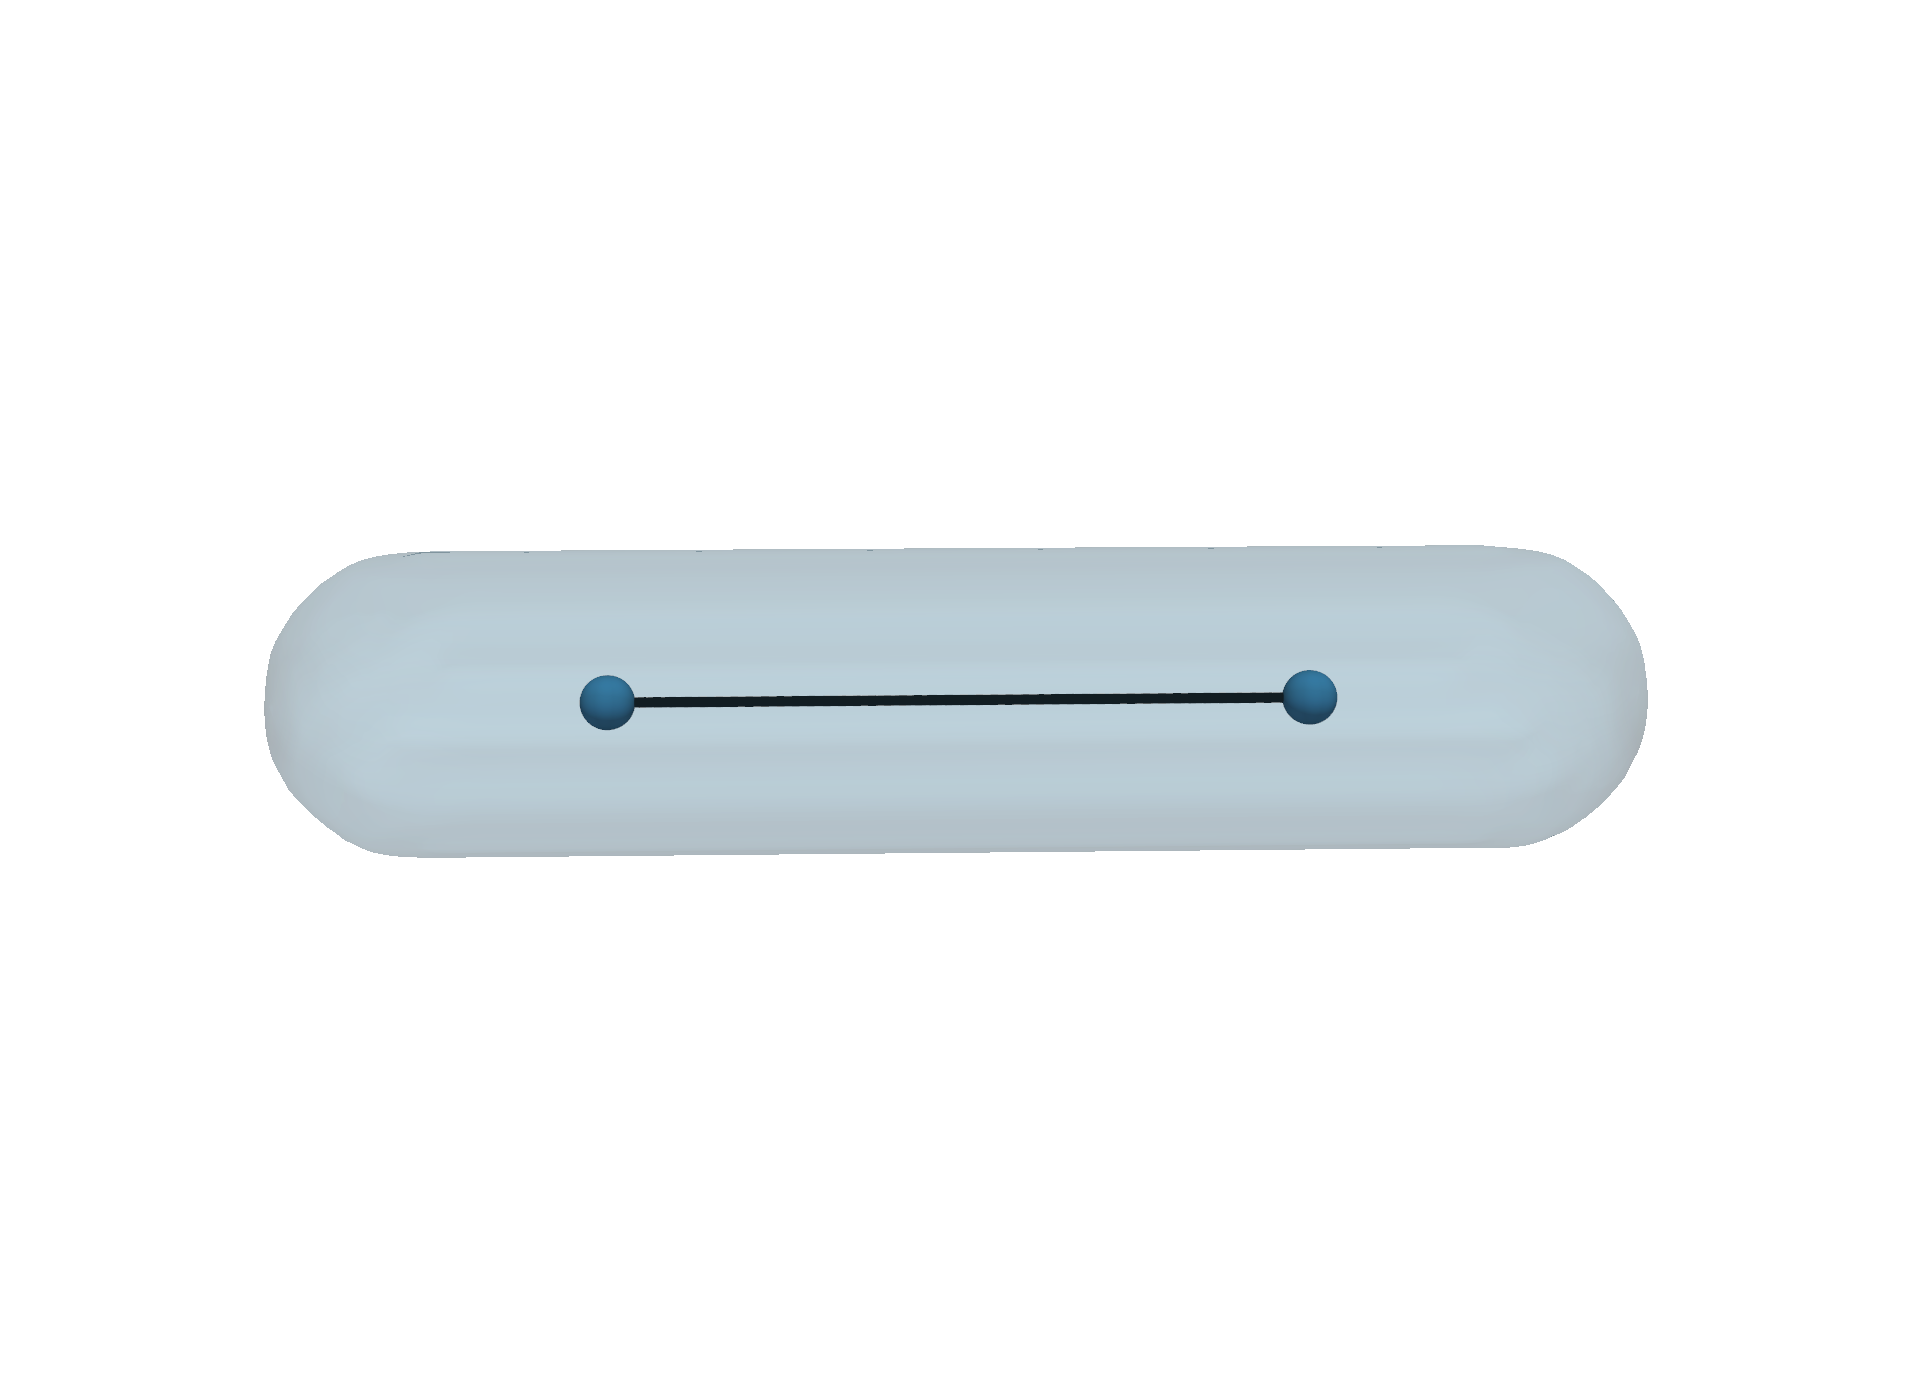

Saved: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\synthetic\exports\fig_synthetic_1_surface_tube.png


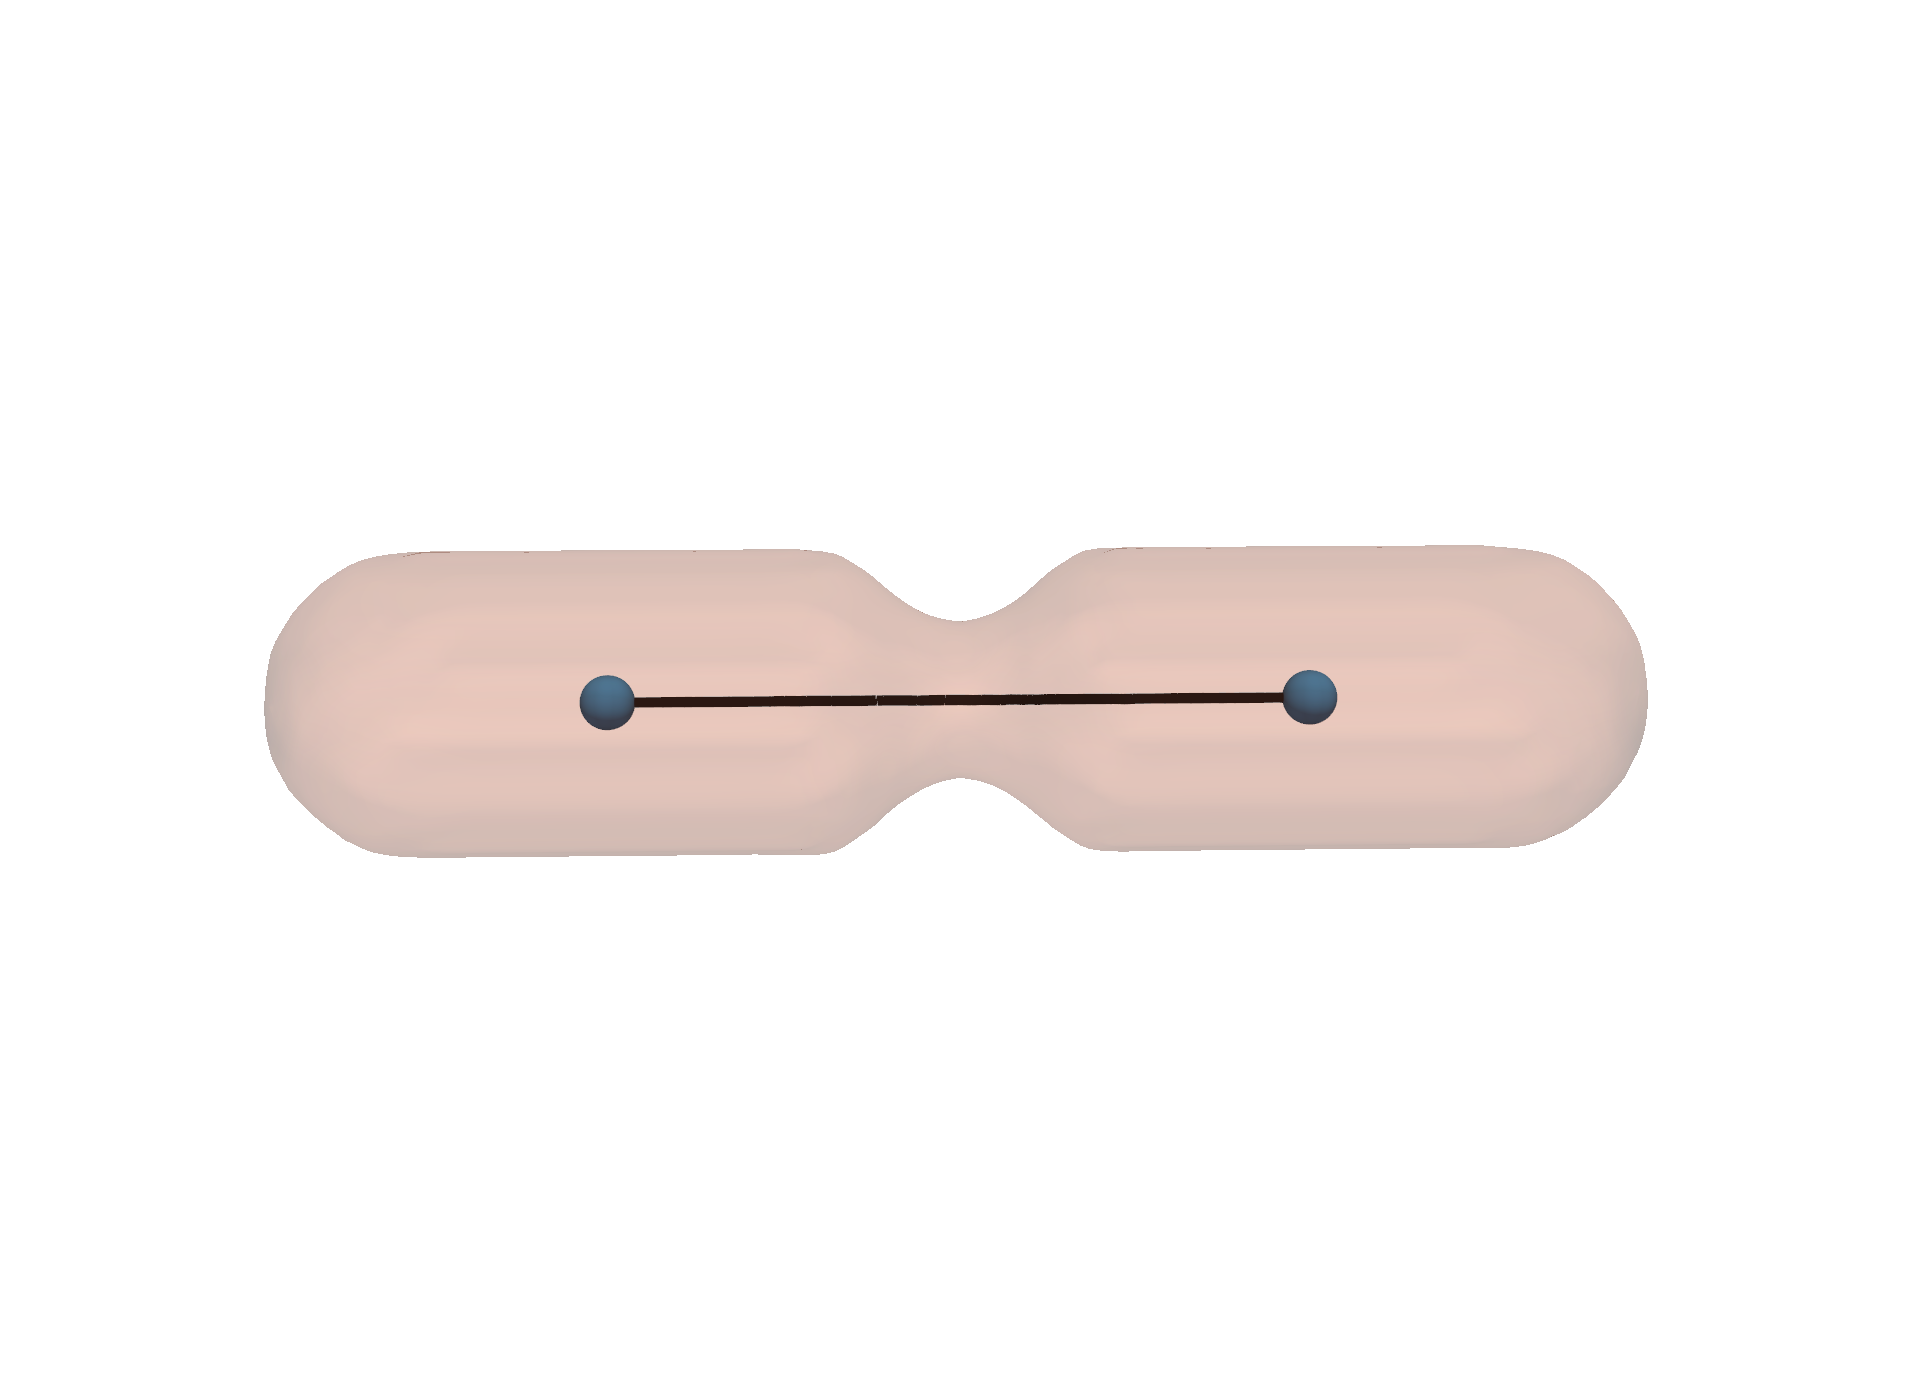

Saved: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\synthetic\exports\fig_synthetic_2_surface_tube.png

Exported figures:
  C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\synthetic\exports\fig_synthetic_1_surface_tube.png
  C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\synthetic\exports\fig_synthetic_2_surface_tube.png


In [ ]:
exported: list[Path] = []
for pid in SYNTHETIC_CASES:
    exported.append(export_synthetic_surface(pid))

print("\nExported figures:")
for p in exported:
    print(f"  {p}")